# Benchmarks Formale
**Scop:** Demonstram ca Voting Ensemble V5 bate reguli simple fara ML

**Benchmarks testate:**
1. Random Classifier - prezice mereu clasa majoritara
2. Momentum Signal - daca SP500 a crescut in ultimele 4 saptamani, prezice V-shape
3. Yield Curve Signal - daca Yield Curve > 0, prezice V-shape
4. VIX Spike Signal - daca VIX > 1.5x media sa pe 60 de zile, prezice V-shape
5. Combined Rule - combinatie simpla de reguli economice

**Acelasi test set** ca V5: 151 saptamani, 3 evenimente nevazute

## 1. Import si Incarcare Date

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics  import (
    roc_auc_score, accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from sklearn.utils    import resample
import pickle

os.makedirs('plots', exist_ok=True)

# Incarcare test set si model V5
# Folosim acelasi test set ca v5_modeling.ipynb
test_df = pd.read_csv('../V5/v5_test.csv', index_col=0, parse_dates=True)

with open('../V5/v5_feature_cols.json') as f:
    feature_cols = json.load(f)

ensemble = pickle.load(open('../V5/models/v5_ensemble.pkl', 'rb'))
scaler   = pickle.load(open('../V5/models/v5_scaler.pkl',   'rb'))

with open('../V5/models/v5_model_meta.json') as f:
    meta = json.load(f)

OPTIMAL_THRESHOLD = meta['optimal_threshold']
N_BOOTSTRAP       = 1000

y_test = test_df['label']

# Features corecte: cele din meta (dupa eliminarea redundantelor)
FEATURE_COLS = meta['feature_cols']  # acestea sunt cele 18 folosite la antrenare

y_test = test_df['label']

# Probabilitati V5 Ensemble
X_test_scaled = pd.DataFrame(
    np.zeros((len(test_df), len(FEATURE_COLS))),
    columns=FEATURE_COLS,
    index=test_df.index
)
for col in FEATURE_COLS:
    if col in test_df.columns:
        X_test_scaled[col] = test_df[col].fillna(0.0).values

v5_proba = ensemble.predict_proba(scaler.transform(X_test_scaled.values))[:, 1]

print('Test set:', len(test_df), 'saptamani')
print('Features folosite:', len(FEATURE_COLS))
print('V-shape in test:', y_test.sum(), '(' + str(round(y_test.mean()*100, 1)) + '%)')
print('V5 AUC referinta:', meta['auc'])

Test set: 151 saptamani
Features folosite: 18
V-shape in test: 47 (31.1%)
V5 AUC referinta: 0.804


## 2. Definire Benchmark-uri

Fiecare benchmark produce o probabilitate sau un scor continuu pentru ROC AUC.

In [3]:
benchmarks = {}

# --- B1: Random Classifier ---
# Prezice V-shape cu probabilitate egala cu frecventa clasei in train
# Echivalent cu AUC=0.5 prin definitie
np.random.seed(42)
v_freq = y_test.mean()  # proportia V-shape in test
benchmarks['Random'] = np.random.uniform(0, 1, len(y_test))
print('B1 Random: probabilitati uniforme')

# --- B2: Momentum Signal ---
# Daca Return_4w > 0 (piata a crescut in ultimele 4 saptamani) -> prezice V-shape
# Logica: momentum pozitiv = recuperare in curs
# Convertim in probabilitate: sigmoid(Return_4w * 10)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

momentum    = test_df['Return_4w'].fillna(0)
benchmarks['Momentum Signal'] = sigmoid(momentum * 10).values
print('B2 Momentum Signal: bazat pe Return_4w')

# --- B3: Yield Curve Signal ---
# Daca Yield Curve > 0 (normala, nu invertita) -> mai probabil V-shape
# Yield curve negativa = recesiune probabila = Non-V
yield_curve = test_df['Yield_Curve'].fillna(0)
benchmarks['Yield Curve Signal'] = sigmoid(yield_curve * 2).values
print('B3 Yield Curve Signal: bazat pe Yield_Curve (10Y-2Y)')

# --- B4: VIX Spike Signal ---
# Daca VIX_Ratio > 1.5 (VIX mult mai mare decat media sa) -> capitulare -> V-shape
# Logica: frica extrema = potential punct de intoarcere
vix_ratio = test_df['VIX_Ratio'].fillna(1.0)
benchmarks['VIX Spike Signal'] = sigmoid((vix_ratio - 1.0) * 3).values
print('B4 VIX Spike Signal: bazat pe VIX_Ratio')

# --- B5: Combined Rule ---
# Medie simpla a semnalelor B2 + B3 + B4
# Reprezinta un investitor sofisticat fara ML
benchmarks['Combined Rule'] = (
    benchmarks['Momentum Signal'] +
    benchmarks['Yield Curve Signal'] +
    benchmarks['VIX Spike Signal']
) / 3
print('B5 Combined Rule: media B2 + B3 + B4')

# Adaugam V5 pentru comparatie
benchmarks['V5 Ensemble (ours)'] = v5_proba

print('\nToti benchmark-urile definite.')

B1 Random: probabilitati uniforme
B2 Momentum Signal: bazat pe Return_4w
B3 Yield Curve Signal: bazat pe Yield_Curve (10Y-2Y)
B4 VIX Spike Signal: bazat pe VIX_Ratio
B5 Combined Rule: media B2 + B3 + B4

Toti benchmark-urile definite.


## 3. Evaluare si Bootstrap CI per Benchmark

In [4]:
def evaluate_with_bootstrap(y_true, y_score, n_bootstrap=1000, threshold=0.5):
    auc  = roc_auc_score(y_true, y_score)
    pred = (y_score >= threshold).astype(int)
    acc  = accuracy_score(y_true, pred)
    f1   = f1_score(y_true, pred, pos_label=1, zero_division=0)

    boot_aucs = []
    for i in range(n_bootstrap):
        ys, ps = resample(y_true, y_score, random_state=i)
        if len(np.unique(ys)) < 2:
            continue
        boot_aucs.append(roc_auc_score(ys, ps))

    ci_low  = np.percentile(boot_aucs, 2.5)
    ci_high = np.percentile(boot_aucs, 97.5)

    return {
        'AUC'     : round(auc, 3),
        'CI_low'  : round(ci_low, 3),
        'CI_high' : round(ci_high, 3),
        'Accuracy': round(acc, 3),
        'F1'      : round(f1, 3)
    }

results = {}
for name, scores in benchmarks.items():
    t = OPTIMAL_THRESHOLD if name == 'V5 Ensemble (ours)' else 0.5
    results[name] = evaluate_with_bootstrap(y_test.values, scores,
                                            N_BOOTSTRAP, threshold=t)
    r = results[name]
    print(name.ljust(25),
          '| AUC=' + str(r['AUC']),
          '[' + str(r['CI_low']) + ', ' + str(r['CI_high']) + ']',
          '| Acc=' + str(r['Accuracy']),
          '| F1=' + str(r['F1']))

Random                    | AUC=0.434 [0.331, 0.534] | Acc=0.444 | F1=0.288
Momentum Signal           | AUC=0.54 [0.431, 0.647] | Acc=0.57 | F1=0.435
Yield Curve Signal        | AUC=0.512 [0.42, 0.603] | Acc=0.417 | F1=0.488
VIX Spike Signal          | AUC=0.506 [0.397, 0.608] | Acc=0.51 | F1=0.393
Combined Rule             | AUC=0.517 [0.427, 0.607] | Acc=0.43 | F1=0.488
V5 Ensemble (ours)        | AUC=0.804 [0.72, 0.88] | Acc=0.795 | F1=0.659


## 4. ROC Curves - Toate Benchmark-urile

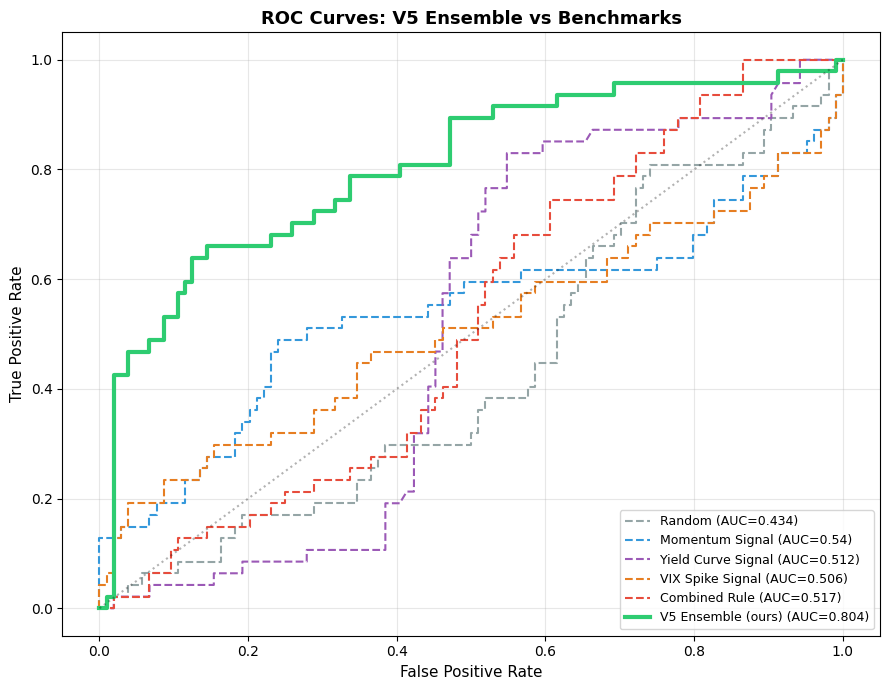

Salvat: plots/benchmarks_roc.png


In [5]:
colors = {
    'Random'            : '#95a5a6',
    'Momentum Signal'   : '#3498db',
    'Yield Curve Signal': '#9b59b6',
    'VIX Spike Signal'  : '#e67e22',
    'Combined Rule'     : '#e74c3c',
    'V5 Ensemble (ours)': '#2ecc71'
}

fig, ax = plt.subplots(figsize=(9, 7))

for name, scores in benchmarks.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc         = results[name]['AUC']
    lw          = 3   if name == 'V5 Ensemble (ours)' else 1.5
    style       = '-' if name == 'V5 Ensemble (ours)' else '--'
    ax.plot(fpr, tpr, color=colors[name], linewidth=lw, linestyle=style,
            label=name + ' (AUC=' + str(auc) + ')')

ax.plot([0,1],[0,1], 'k:', alpha=0.3)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves: V5 Ensemble vs Benchmarks', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/benchmarks_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/benchmarks_roc.png')

## 5. Comparatie AUC cu CI - Bar Chart

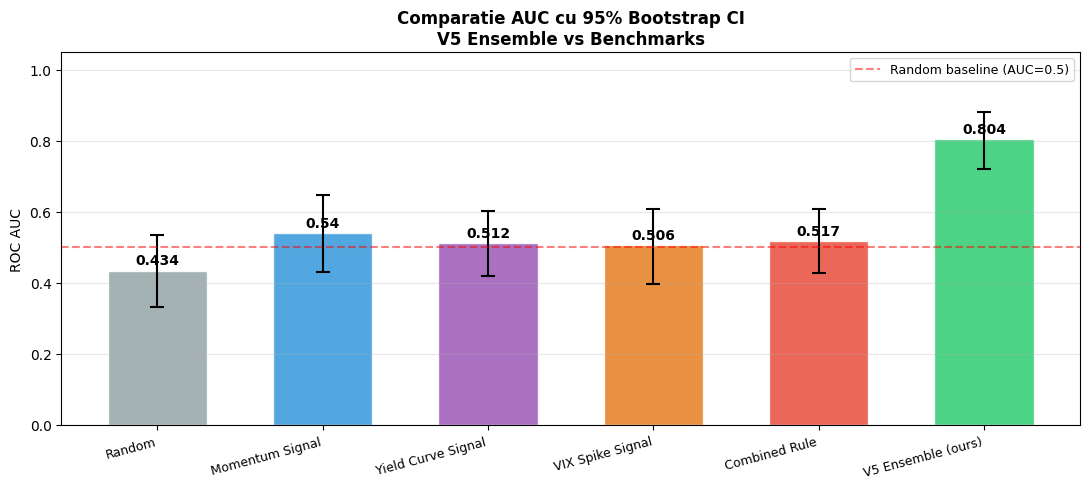

Salvat: plots/benchmarks_comparison.png


In [6]:
names  = list(results.keys())
aucs   = [results[n]['AUC']    for n in names]
ci_low = [results[n]['CI_low'] for n in names]
ci_hi  = [results[n]['CI_high']for n in names]
errs   = [[aucs[i] - ci_low[i] for i in range(len(names))],
           [ci_hi[i] - aucs[i]  for i in range(len(names))]]

bar_colors = [colors[n] for n in names]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(names, aucs, color=bar_colors, edgecolor='white',
              width=0.6, alpha=0.85)
ax.errorbar(names, aucs, yerr=errs, fmt='none',
            color='black', capsize=5, capthick=1.5, linewidth=1.5)

for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            str(auc), ha='center', va='bottom',
            fontweight='bold', fontsize=10)

ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline (AUC=0.5)')
ax.set_ylabel('ROC AUC')
ax.set_ylim(0, 1.05)
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
ax.set_title('Comparatie AUC cu 95% Bootstrap CI\nV5 Ensemble vs Benchmarks',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/benchmarks_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/benchmarks_comparison.png')

## 6. Tabel Complet pentru Paper

In [7]:
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model', 'AUC', 'CI_low', 'CI_high', 'Accuracy', 'F1']
results_df['CI'] = '[' + results_df['CI_low'].astype(str) + ', ' + results_df['CI_high'].astype(str) + ']'
results_df['Beat_Random'] = results_df['AUC'] > 0.5
results_df = results_df.sort_values('AUC', ascending=False).reset_index(drop=True)
results_df.index += 1

results_df.to_csv('data/benchmarks_results.csv', index=False)

separator = '=' * 65
print('TABEL BENCHMARKS - PENTRU PAPER')
print(separator)
print(results_df[['Model', 'AUC', 'CI', 'Accuracy', 'F1', 'Beat_Random']].to_string())
print()

v5_auc   = results['V5 Ensemble (ours)']['AUC']
best_bm  = max({k: v for k, v in results.items() if k != 'V5 Ensemble (ours)'},
               key=lambda k: results[k]['AUC'])
best_auc = results[best_bm]['AUC']
margin   = round(v5_auc - best_auc, 3)
n_beaten = sum(1 for k, v in results.items()
               if k != 'V5 Ensemble (ours)' and v5_auc > v['AUC'])

print('FRAZE PENTRU PAPER:')
print(separator)
print('"The V5 Voting Ensemble (AUC=' + str(v5_auc) + ') outperforms all')
print(str(len(results)-1) + ' benchmark strategies.')
print('The best non-ML benchmark, ' + best_bm + ', achieves AUC=' + str(best_auc) + ',')
print('representing a margin of +' + str(margin) + ' in favor of the ensemble."')

TABEL BENCHMARKS - PENTRU PAPER
                Model    AUC              CI  Accuracy     F1  Beat_Random
1  V5 Ensemble (ours)  0.804    [0.72, 0.88]     0.795  0.659         True
2     Momentum Signal  0.540  [0.431, 0.647]     0.570  0.435         True
3       Combined Rule  0.517  [0.427, 0.607]     0.430  0.488         True
4  Yield Curve Signal  0.512   [0.42, 0.603]     0.417  0.488         True
5    VIX Spike Signal  0.506  [0.397, 0.608]     0.510  0.393         True
6              Random  0.434  [0.331, 0.534]     0.444  0.288        False

FRAZE PENTRU PAPER:
"The V5 Voting Ensemble (AUC=0.804) outperforms all
5 benchmark strategies.
The best non-ML benchmark, Momentum Signal, achieves AUC=0.54,
representing a margin of +0.264 in favor of the ensemble."
